# 5. Tidal Heating Basics

A world with a non-zero eccentricity or obliquity, or one that is rotating non-synchronously, is flexed by its host's gravity. The internal friction of that flexing dissipates orbital and rotational energy as heat. To compute it, attach a tide model to a world and call `calc_tides` with the orbital and spin state.

The constant phase lag (fixed-Q) model writes the tidal response as a Love number $k$ with a fixed lag set by a quality factor $Q$. It is analytic and needs no interior detail. This notebook applies it to Io and sweeps the heating against eccentricity and against $Q$. Interior rheology, which makes $k$ and the lag depend on frequency, is discussed in a later notebook.


In [1]:
%matplotlib inline
import timeit
import numpy as np
import matplotlib.pyplot as plt

from TidalPy.constants import G, M_jup
from TidalPy.structures_x.configs import build_world
from TidalPy.Tides_x.classes import make_tide

# A simple Io: an iron core under a rocky mantle.
io_config = {
    "schema_version": "0.2.0", "name": "Io", "type": "terrestrial",
    "radius_m": 1.8216e6, "mass_kg": 8.9319e22, "spin_frequency_rad_s": 4.11e-5,
    "layers": {
        "core":   {"class": "physics", "type": "iron", "layer_index": 0,
                   "radius_outer_m": 9.0e5, "is_tidal": False},
        "mantle": {"class": "solidliquid", "type": "mantle_rock", "layer_index": 1,
                   "radius_fraction": 1.0, "is_tidal": True},
    },
}
io = build_world(io_config)

# Jupiter as the tidal host and Io's orbit.
A_IO = 4.217e8                     # semi-major axis, meters
E_IO = 0.0041                      # present-day forced eccentricity
n = np.sqrt(G * M_jup / A_IO**3)   # mean motion; Io rotates synchronously
print(f"Io mean motion: {n:.4e} rad/s   (period {2*np.pi/n/86400:.2f} days)")

Io mean motion: 4.1102e-05 rad/s   (period 1.77 days)


## Attaching a Fixed-Q Tide

Build a fixed-Q model with a Love number $k_2$ and quality factor $Q$, attach it, set the tidal harmonic configuration, and call `calc_tides`. The fixed $k$ and $Q$ values are per tidal degree, given as lists indexed from degree l = 2.

In [2]:
tide = make_tide(
    "fixed_q",
    {"fixed_k": [0.3],   # list is over harmonic degree l starting at l=min_degree_l; put as many as you want to use in the calculations
     "fixed_q": [100.0]}
)

io.set_tide_model(tide)
# Eccentricity truncations are based on the unsquared eccentricity functions, same for obliquity truncations
# To get the typical tidal heating equation use eccentricity_truncation=1; obliquity_truncation=0
io.set_tide_config(min_degree_l=2, max_degree_l=2, eccentricity_truncation=1, obliquity_truncation=0)
io.set_spin_frequency(n)   # synchronous rotation

io.calc_tides(orbital_frequency=n, spin_frequency=n, eccentricity=E_IO,
              obliquity=0.0, semi_major_axis=A_IO, host_mass=M_jup)

heating = io.get_tidal_heating()
surface_flux = heating / io.calc_surface_area(io.radius)
print(f"total tidal heating : {heating:.3e} W")
print(f"surface heat flux   : {surface_flux:.2f} W/m^2")
print("(Io's observed output is about 1e14 W, or roughly 2 W/m^2, depending on k2 and Q.)")

total tidal heating : 1.867e+13 W
surface heat flux   : 0.45 W/m^2
(Io's observed output is about 1e14 W, or roughly 2 W/m^2, depending on k2 and Q.)


## Dependence on Eccentricity

Tidal heating is driven by the changing distance and rate over an eccentric orbit. To leading order it grows as the square of the eccentricity. The sweep covers a large range of eccentricity using the standard $e^2$ truncation as well as a $e^{20}$ to showcase how they diverge at large eccentricity. The trade off is that calculating with a higher truncation is slightly slower to calculate.

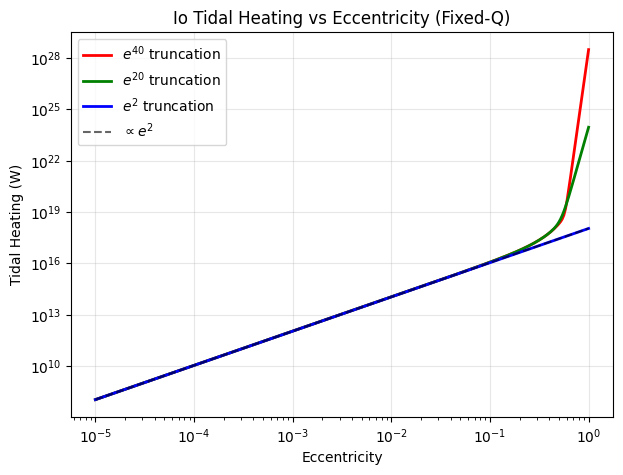


Calculating e^2 truncation...


3.12 μs ± 6.4 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
... is slightly faster than using e^20 truncation...


6.35 μs ± 404 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
... is quite a bit faster than using e^40 truncation...


10.8 μs ± 193 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [3]:
eccs = np.logspace(-5, 0, 300)

# Build a 2nd Io to work with higher truncation levels
io_high_e = build_world(io_config)
tide = make_tide("fixed_q", {"fixed_k": [0.3], "fixed_q": [100.0]})
io_high_e.set_tide_model(tide)
io_high_e.set_tide_config(min_degree_l=2, max_degree_l=2, eccentricity_truncation=10, obliquity_truncation=0)
io_high_e.set_spin_frequency(n)

io_super_high_e = build_world(io_config)
tide = make_tide("fixed_q", {"fixed_k": [0.3], "fixed_q": [100.0]})
io_super_high_e.set_tide_model(tide)
io_super_high_e.set_tide_config(min_degree_l=2, max_degree_l=2, eccentricity_truncation=20, obliquity_truncation=0)
io_super_high_e.set_spin_frequency(n)

heat = []
heat_high_e = []
heat_super_high_e = []
for e in eccs:
    io.calc_tides(n, n, e, 0.0, A_IO, M_jup)
    heat.append(io.get_tidal_heating())
    
    io_high_e.calc_tides(n, n, e, 0.0, A_IO, M_jup)
    heat_high_e.append(io_high_e.get_tidal_heating())

    io_super_high_e.calc_tides(n, n, e, 0.0, A_IO, M_jup)
    heat_super_high_e.append(io_super_high_e.get_tidal_heating())
heat = np.array(heat)
heat_high_e = np.array(heat_high_e)
heat_super_high_e = np.array(heat_super_high_e)

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(eccs, heat_super_high_e, lw=2, label="$e^{40}$ truncation", c='r')
ax.loglog(eccs, heat_high_e, lw=2, label="$e^{20}$ truncation", c='g')
ax.loglog(eccs, heat, lw=2, label="$e^{2}$ truncation", c='b')
ax.loglog(eccs, heat[0] * (eccs / eccs[0])**2, "k--", alpha=0.6, label=r"$\propto e^2$")
ax.set_xlabel("Eccentricity")
ax.set_ylabel("Tidal Heating (W)")
ax.set_title("Io Tidal Heating vs Eccentricity (Fixed-Q)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

print()
print("Calculating e^2 truncation...")
%timeit io.calc_tides(orbital_frequency=n, spin_frequency=n, eccentricity=E_IO, obliquity=0.0, semi_major_axis=A_IO, host_mass=M_jup)
print("... is slightly faster than using e^20 truncation...")
%timeit io_high_e.calc_tides(orbital_frequency=n, spin_frequency=n, eccentricity=E_IO, obliquity=0.0, semi_major_axis=A_IO, host_mass=M_jup)
print("... is quite a bit faster than using e^40 truncation...")
%timeit io_super_high_e.calc_tides(orbital_frequency=n, spin_frequency=n, eccentricity=E_IO, obliquity=0.0, semi_major_axis=A_IO, host_mass=M_jup)

## Dependence on the Quality Factor

The quality factor $Q$ measures how lossy the body is: a smaller $Q$ means more dissipation per cycle, with the heating inversely proportional to $Q$. The three values below bracket the plausible range.

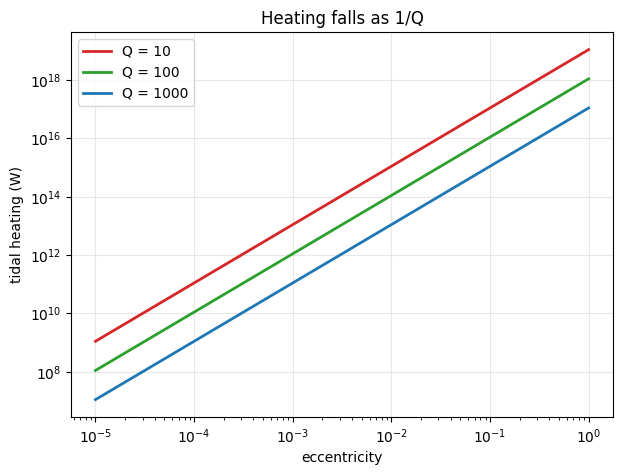

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
for q, color in [(10.0, "tab:red"), (100.0, "tab:green"), (1000.0, "tab:blue")]:
    io.set_tide_model(make_tide("fixed_q", {"fixed_k": [0.3], "fixed_q": [q]}))
    io.set_tide_config(min_degree_l=2, max_degree_l=2, eccentricity_truncation=1, obliquity_truncation=0)
    heat = []
    for e in eccs:
        io.calc_tides(n, n, e, 0.0, A_IO, M_jup)
        heat.append(io.get_tidal_heating())
    ax.loglog(eccs, heat, color=color, lw=2, label=f"Q = {q:.0f}")
ax.set_xlabel("eccentricity")
ax.set_ylabel("tidal heating (W)")
ax.set_title("Heating falls as 1/Q")
ax.legend()
ax.grid(alpha=0.3)
plt.show()
